<a href="https://colab.research.google.com/github/Sharmika-18/Task-5/blob/main/DATA_CLEANING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving AB_NYC_2019.csv to AB_NYC_2019.csv


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("AB_NYC_2019.csv")

# Check structure
print(df.info())
print(df.describe())

# Convert date column
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Ensure numeric columns are numeric
numeric_cols = [
    'price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
print(df.isnull().sum())



id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                 10051
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
df[df['reviews_per_month'].isnull()]['number_of_reviews'].unique()
df['host_name'].fillna("Unknown Host", inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')


/tmp/ipython-input-1841143768.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna("Unknown Host", inplace=True)
/tmp/ipython-input-1841143768.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
print(df.isnull().sum())


id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
text_cols = ['name', 'host_name', 'neighbourhood', 'neighbourhood_group', 'room_type']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()
df['room_type'] = df['room_type'].replace({
    'Entire home/apt': 'Entire Home/Apt',
    'Private room': 'Private Room',
    'Shared room': 'Shared Room'
})

df = df[(df['latitude'].between(-90, 90)) &
        (df['longitude'].between(-180, 180))]


In [ ]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'minimum_nights')
df = remove_outliers_iqr(df, 'number_of_reviews')


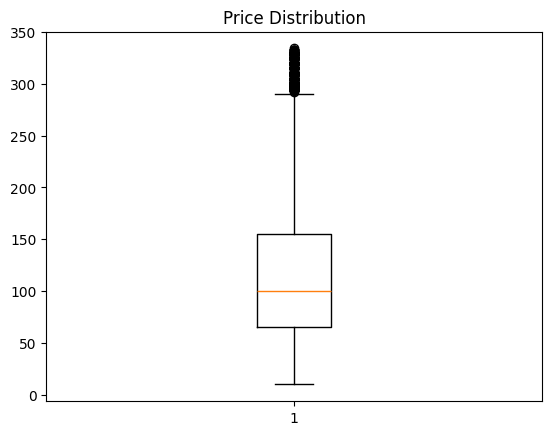

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['price'])
plt.title("Price Distribution")
plt.show()


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)
print("Cleaning Completed Successfully ✅")


Cleaning Completed Successfully ✅
